# PerceptSent Agreement — Ground Truth & Evaluation (Cross-Validation)

**Purpose:**
1. Characterise the 12 agreement-filtered subsets (sigma × population threshold).
2. Produce reproducible **5-Fold Cross-Validation splits** (`random_state=42`) for each CSV.
3. Evaluate MLLM annotation outputs against the ground truth across folds.
4. Save all metrics, confusion matrices, and figures to disk.

In [1]:
## 1  Environment
import sys
from pathlib import Path

try:
    ROOT = Path(__file__).resolve().parent.parent
except NameError:
    _cwd = Path.cwd()
    ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd

sys.path.insert(0, str(ROOT / "src"))

import warnings
warnings.filterwarnings("ignore")

import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, cohen_kappa_score, roc_auc_score,
    accuracy_score, mean_absolute_error,
)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.5)
PALETTE = sns.color_palette("muted")

AGREEMENT_DIR = ROOT / "data" / "perceptsent-agreement"
OUTPUT_DIR    = ROOT / "outputs"
FIGURES_DIR   = ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def _save_fig(fig, stem: str) -> None:
    """Save figure as both PDF and PNG at 300 dpi."""
    for ext in ("pdf", "png"):
        fig.savefig(FIGURES_DIR / f"{stem}.{ext}", bbox_inches="tight", dpi=300)
    print(f"Saved → {stem}  [.pdf + .png]")

SENTIMENT_MAPS: dict[str, dict[str, int]] = {
    "p2neg": {
        "Positive":         1,
        "SlightlyPositive": 1,
        "Neutral":          0,
        "SlightlyNegative": 0,
        "Negative":         0,
    },
    "p2plus": {
        "Positive":         0,
        "SlightlyPositive": 0,
        "Neutral":          0,
        "SlightlyNegative": 1,
        "Negative":         1,
    },
    "p3": {
        "Positive":         2,
        "SlightlyPositive": 2,
        "Neutral":          0,
        "SlightlyNegative": 1,
        "Negative":         1,
    },
    "p5": {
        "Positive":         4,
        "SlightlyPositive": 3,
        "Neutral":          2,
        "SlightlyNegative": 1,
        "Negative":         0,
    },
}

PROBLEM_TYPE: dict[str, str] = {
    "p2neg":  "binary",
    "p2plus": "binary",
    "p3":     "multiclass-3",
    "p5":     "ordinal-5",
}

p_order = ["p2neg", "p2plus", "p3", "p5"]

print(f"Root             : {ROOT}")
print(f"Agreement CSVs   : {AGREEMENT_DIR}")
print(f"Figures          : {FIGURES_DIR}")

Root             : /mnt/raid5/neemias/mllm-persona-simulation-urbcom
Agreement CSVs   : /mnt/raid5/neemias/mllm-persona-simulation-urbcom/data/perceptsent-agreement
Figures          : /mnt/raid5/neemias/mllm-persona-simulation-urbcom/figures


Found 12 CSV files:

  sigma3_p2neg                  n=   50  classes=2  [label 0=33  label 1=17]
  sigma3_p2plus                 n=   50  classes=2  [label 0=30  label 1=20]
  sigma3_p3                     n=   45  classes=3  [label 0=8  label 1=20  label 2=17]
  sigma3_p5                     n=   36  classes=5  [label 0=8  label 1=8  label 2=8  label 3=4  label 4=8]
  sigma4_p2neg                  n=   41  classes=2  [label 0=28  label 1=13]
  sigma4_p2plus                 n=   43  classes=2  [label 0=26  label 1=17]
  sigma4_p3                     n=   34  classes=3  [label 0=4  label 1=17  label 2=13]
  sigma4_p5                     n=   16  classes=4  [label 0=4  label 1=2  label 2=4  label 4=6]
  sigma5_p2neg                  n=   28  classes=2  [label 0=19  label 1=9]
  sigma5_p2plus                 n=   24  classes=2  [label 0=15  label 1=9]
  sigma5_p3                     n=   18  classes=2  [label 1=9  label 2=9]
  sigma5_p5                     n=    4  classes=2  [label 0=2 

Saved → fig_pa01_dataset_overview  [.pdf + .png]


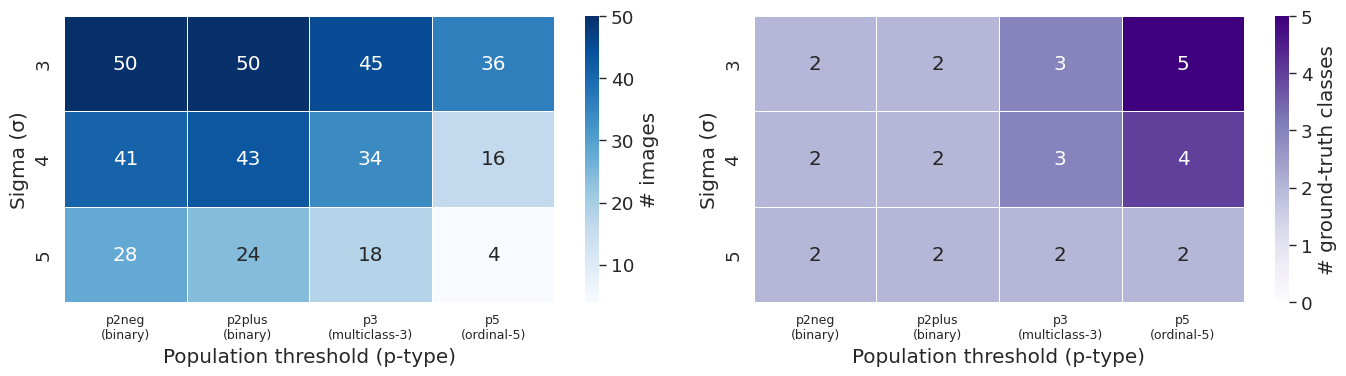

In [2]:
## 2  Load & Characterise All CSVs
_PAT = re.compile(r"percept_dataset_sigma(\d+)_(p\w+)\.csv")

csv_files = sorted(AGREEMENT_DIR.glob("*.csv"))
print(f"Found {len(csv_files)} CSV files:\n")

datasets: dict[str, pd.DataFrame] = {}
meta_rows = []

for fpath in csv_files:
    m = _PAT.match(fpath.name)
    if not m:
        continue
    sigma, p_type = int(m.group(1)), m.group(2)
    key = f"sigma{sigma}_{p_type}"

    df = pd.read_csv(fpath)
    n_total      = len(df)
    label_counts = df["ground_truth"].value_counts().sort_index().to_dict()
    n_classes    = df["ground_truth"].nunique()

    datasets[key] = df
    meta_rows.append({
        "key":       key,
        "sigma":     sigma,
        "p_type":    p_type,
        "problem":   PROBLEM_TYPE.get(p_type, "unknown"),
        "filename":  fpath.name,
        "n_total":   n_total,
        "n_classes": n_classes,
        "label_dist": label_counts,
    })
    dist_str = "  ".join(f"label {k}={v}" for k, v in label_counts.items())
    print(f"  {key:28s}  n={n_total:5,}  classes={n_classes}  [{dist_str}]")

meta_df = pd.DataFrame(meta_rows)

# ── Dataset sizes ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pivot_size = meta_df.pivot(index="sigma", columns="p_type", values="n_total").reindex(columns=p_order)
pivot_cls  = meta_df.pivot(index="sigma", columns="p_type", values="n_classes").reindex(columns=p_order)

sns.heatmap(pivot_size, annot=True, fmt=",.0f", cmap="Blues", linewidths=0.4,
            cbar_kws={"label": "# images"}, ax=axes[0])
axes[0].set_xlabel("Population threshold (p-type)")
axes[0].set_ylabel("Sigma (σ)")

sns.heatmap(pivot_cls, annot=True, fmt="d", cmap="Purples", linewidths=0.4,
            cbar_kws={"label": "# ground-truth classes"}, vmin=0, vmax=5, ax=axes[1])
axes[1].set_xlabel("Population threshold (p-type)")
axes[1].set_ylabel("Sigma (σ)")

for ax in axes:
    ax.set_xticklabels(
        [f"{p}\n({PROBLEM_TYPE.get(p, '?')})" for p in p_order],
        rotation=0, fontsize=9,
    )

plt.tight_layout()
_save_fig(fig, "fig_pa01_dataset_overview")
plt.show()

In [3]:
## 3  Sampling Parameters
# Strategy: use full annotation pool per image (60% resample → ~717 annotations/image).
# CI comes from bootstrap resampling over *images* (not annotation sub-sampling),
# since with ~717 annotations the modal per image is effectively deterministic.

SAMPLE_FRAC    = 0.6   # fraction of annotations resampled per image to compute modal
N_BOOTSTRAP    = 1000  # bootstrap iterations for 95% CI (image-level resample)
BOOTSTRAP_SEED = 42

print(f'SAMPLE_FRAC={SAMPLE_FRAC}  (~{round(1194*SAMPLE_FRAC):.0f} annotations/image)')
print(f'N_BOOTSTRAP={N_BOOTSTRAP}  bootstrap iterations for 95% CI (image-level resample)')


SAMPLE_FRAC=0.6  (~716 annotations/image)
N_BOOTSTRAP=1000  bootstrap iterations for 95% CI (image-level resample)


Saved → fig_pa02_gt_label_distribution  [.pdf + .png]


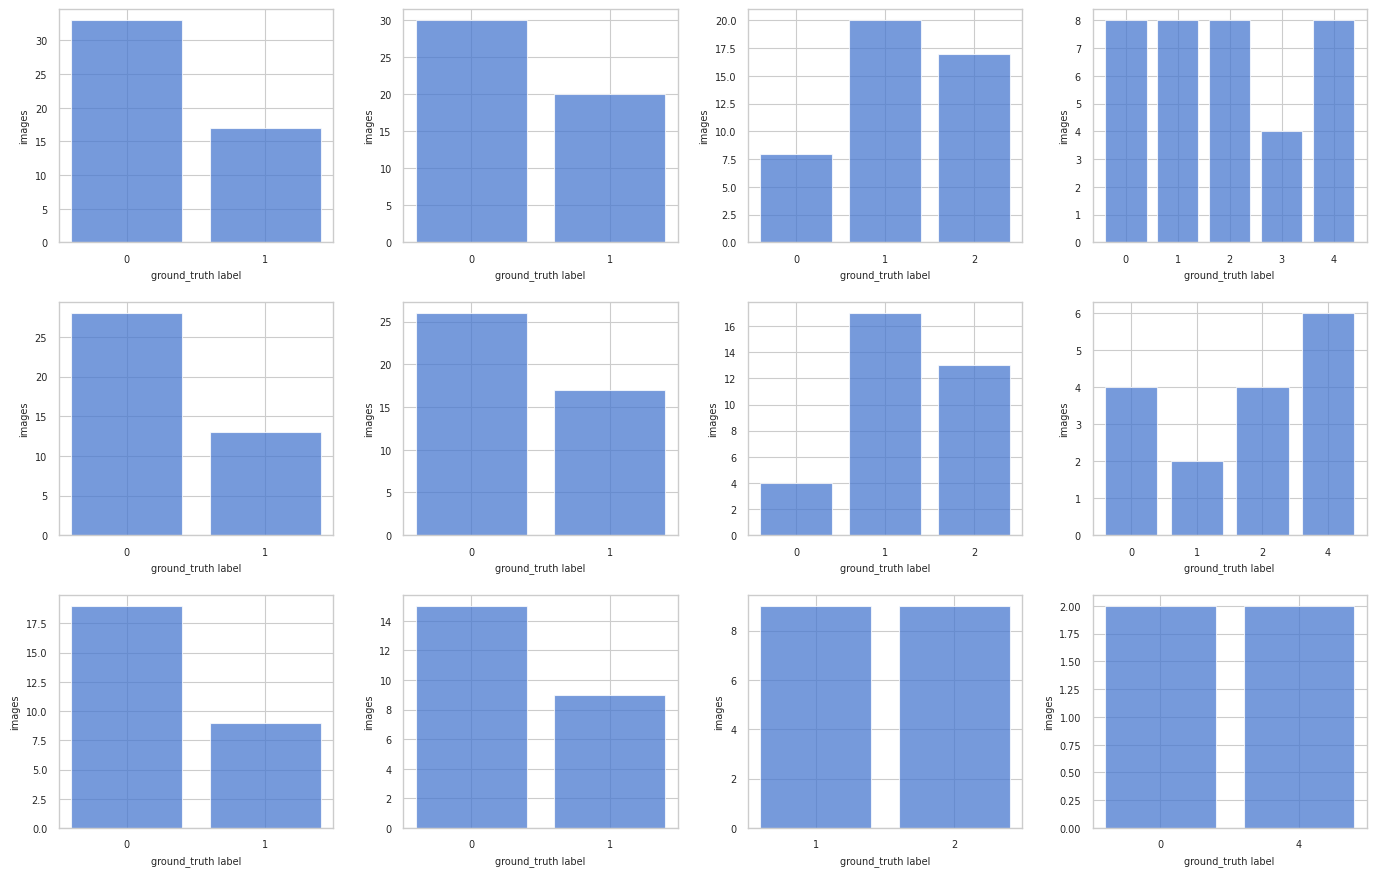

In [4]:
## 4  Ground Truth Statistics
sigma_vals = sorted({int(k.split("_")[0].replace("sigma", "")) for k in datasets})

fig, axes = plt.subplots(len(sigma_vals), len(p_order), figsize=(14, 9), sharey=False)

for row_i, sigma in enumerate(sigma_vals):
    for col_j, p_type in enumerate(p_order):
        ax  = axes[row_i][col_j]
        key = f"sigma{sigma}_{p_type}"
        if key not in datasets:
            ax.set_visible(False)
            continue

        df_key = datasets[key]
        counts = df_key["ground_truth"].value_counts().sort_index()
        ax.bar([str(c) for c in counts.index], counts.values,
               color=PALETTE[0], alpha=0.75, edgecolor="white")
        ax.set_xlabel("ground_truth label", fontsize=7)
        ax.set_ylabel("images", fontsize=7)
        ax.tick_params(labelsize=7)

plt.tight_layout()
_save_fig(fig, "fig_pa02_gt_label_distribution")
plt.show()


In [5]:
## 5  Load MLLM Annotations (raw, not pre-aggregated)
def load_jsonl(path: Path) -> pd.DataFrame:
    if not path.exists():
        print(f'WARNING: {path} not found.')
        return pd.DataFrame()
    records = [json.loads(line.strip()) for line in open(path, encoding='utf-8') if line.strip()]
    return pd.DataFrame(records)

ann_base = load_jsonl(OUTPUT_DIR / 'annotations_baseline.jsonl')

# No-persona conditions (qwen3-vl:8b, same 50 images as baseline)
ann_np_think    = load_jsonl(OUTPUT_DIR / 'annotations_no_persona_think.jsonl')
ann_np_no_think = load_jsonl(OUTPUT_DIR / 'annotations_no_persona_no_think.jsonl')

# Keep only valid predictions
def _filter_valid(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    return df[df['predicted_sentiment'].notna() & (df['predicted_sentiment'] != '')].copy()

ann_base        = _filter_valid(ann_base)
ann_np_think    = _filter_valid(ann_np_think)
ann_np_no_think = _filter_valid(ann_np_no_think)

# Condition registry: label → DataFrame
CONDITION_REGISTRY = {
    'baseline':         ann_base,
    'no_persona_think':    ann_np_think,
    'no_persona_no_think': ann_np_no_think,
}

def modal_per_image(ann: pd.DataFrame) -> pd.DataFrame:
    """Full-pool modal (used for confusion matrices)."""
    if ann.empty:
        return pd.DataFrame(columns=['image_id', 'modal_sentiment'])
    return (ann.groupby('image_id')['predicted_sentiment']
               .agg(lambda x: x.value_counts().index[0])
               .reset_index(name='modal_sentiment'))

def sampled_modal_per_image(ann: pd.DataFrame, frac: float, rng) -> pd.DataFrame:
    """Resample frac of annotations per image, then compute modal.
    Works for any pool size (including single-annotation no-persona rows)."""
    if ann.empty:
        return pd.DataFrame(columns=['image_id', 'modal_sentiment'])
    rows = []
    for img_id, grp in ann.groupby('image_id'):
        n = max(1, int(len(grp) * frac))
        sample = grp.sample(n=n, random_state=int(rng.integers(0, 2**31)))
        modal  = sample['predicted_sentiment'].value_counts().index[0]
        rows.append({'image_id': img_id, 'modal_sentiment': modal})
    return pd.DataFrame(rows)

modal_base_full     = modal_per_image(ann_base)
modal_np_think_full = modal_per_image(ann_np_think)
modal_np_no_think_full = modal_per_image(ann_np_no_think)

def _describe(label, df):
    if df.empty:
        print(f'{label:<30s}: not available')
        return
    n_img = df['image_id'].nunique()
    ann_per = len(df) / n_img if n_img else 0
    print(f'{label:<30s}: {len(df):>7,} annotations  |  {n_img:>3} images  |  {ann_per:.1f} ann/image')

_describe('Baseline (demographic persona)', ann_base)
_describe('No-persona think=True',          ann_np_think)
_describe('No-persona think=False',         ann_np_no_think)

Baseline (demographic persona):  59,708 annotations  |   50 images  |  1194.2 ann/image
No-persona think=True         :      50 annotations  |   50 images  |  1.0 ann/image
No-persona think=False        :      50 annotations  |   50 images  |  1.0 ann/image


Evaluation complete — 36 rows

  [baseline]
          key  n_images  ann_per_image  f1_macro_mean  cohen_kappa_mean
 sigma3_p2neg        50            716         0.8069            0.6154
sigma3_p2plus        50            716         0.7971            0.5968
    sigma3_p3        45            716         0.5878            0.4482
    sigma3_p5        36            716         0.3088            0.7912
 sigma4_p2neg        41            716         0.8423            0.6878
sigma4_p2plus        43            716         0.8586            0.7196
    sigma4_p3        34            716         0.7077            0.6868
    sigma4_p5        16            716         0.5141            0.8491
 sigma5_p2neg        28            716         1.0000            1.0000
sigma5_p2plus        24            716         1.0000            1.0000
    sigma5_p3        18            716         1.0000            1.0000
    sigma5_p5         4            716         1.0000            1.0000

  [no_persona_think

Saved → fig_pa03_metrics_baseline  [.pdf + .png]


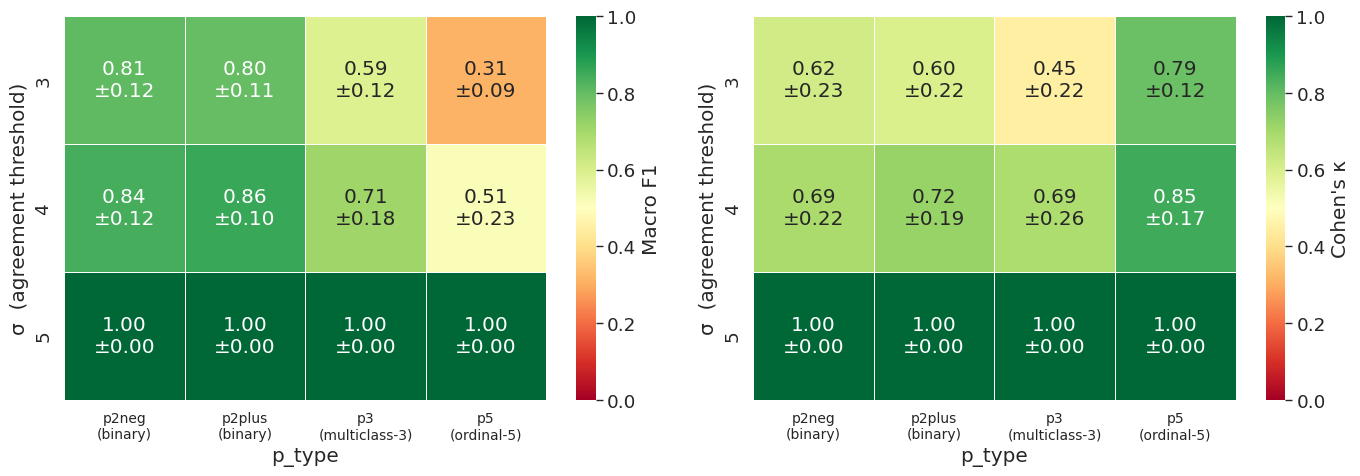

In [6]:
## 6  Evaluation — all conditions, image bootstrap for 95% CI

def _compute_metrics(y_true, y_pred, problem, smap):
    m = {'accuracy': accuracy_score(y_true, y_pred)}
    present_labels = sorted(set(y_true.tolist()))
    if problem == 'binary':
        m['f1_macro']    = f1_score(y_true, y_pred, average='macro',
                                    labels=present_labels, zero_division=0)
        m['f1_pos']      = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
        m['cohen_kappa'] = cohen_kappa_score(y_true, y_pred, weights=None)
        try:
            m['roc_auc'] = roc_auc_score(y_true, y_pred)
        except ValueError:
            pass
    elif problem == 'multiclass-3':
        m['f1_macro']    = f1_score(y_true, y_pred, average='macro',
                                    labels=present_labels, zero_division=0)
        m['cohen_kappa'] = cohen_kappa_score(y_true, y_pred, weights='linear')
    elif problem == 'ordinal-5':
        m['f1_macro']    = f1_score(y_true, y_pred, average='macro',
                                    labels=present_labels, zero_division=0)
        m['cohen_kappa'] = cohen_kappa_score(y_true, y_pred, weights='quadratic')
        m['mae']         = mean_absolute_error(y_true, y_pred)
    return m


def evaluate_cv(key: str, p_type: str, df: pd.DataFrame,
                ann: pd.DataFrame, condition: str) -> dict:
    base = {'key': key, 'condition': condition,
            'p_type': p_type, 'problem': PROBLEM_TYPE.get(p_type, '?')}
    if ann.empty:
        return {**base, 'note': 'no annotations'}

    smap    = SENTIMENT_MAPS[p_type]
    problem = PROBLEM_TYPE[p_type]

    rng_modal = np.random.default_rng(BOOTSTRAP_SEED)

    # For no-persona (1 annotation/image) frac clamps to 1 — still valid.
    modal_df  = sampled_modal_per_image(ann, SAMPLE_FRAC, rng_modal)

    merged = df.merge(modal_df, on='image_id', how='inner')
    if merged.empty or merged['ground_truth'].nunique() < 2:
        return {**base, 'note': 'insufficient data'}

    y_true_all = merged['ground_truth'].values
    y_pred_raw = merged['modal_sentiment'].map(smap)
    valid_mask = y_pred_raw.notna()
    y_true_all = y_true_all[valid_mask]
    y_pred_all = y_pred_raw[valid_mask].values.astype(int)
    n_images   = len(y_true_all)

    if n_images < 2 or len(set(y_true_all.tolist())) < 2:
        return {**base, 'note': 'insufficient data after mapping'}

    try:
        point = _compute_metrics(y_true_all, y_pred_all, problem, smap)
    except Exception as e:
        return {**base, 'note': f'metric error: {e}'}

    rng_boot     = np.random.default_rng(BOOTSTRAP_SEED + 1)
    boot_results = []
    for _ in range(N_BOOTSTRAP):
        idx = rng_boot.integers(0, n_images, size=n_images)
        yt  = y_true_all[idx]
        yp  = y_pred_all[idx]
        if len(set(yt.tolist())) < 2:
            continue
        try:
            boot_results.append(_compute_metrics(yt, yp, problem, smap))
        except Exception:
            pass

    n_img_in_ann = ann['image_id'].nunique()
    ann_per_img  = round(len(ann) / n_img_in_ann * SAMPLE_FRAC) if n_img_in_ann else 0

    result = {
        **base,
        'n_images':      n_images,
        'ann_per_image': int(ann_per_img),
        'n_annotations': int(n_images * ann_per_img),
    }
    for metric in ['accuracy', 'f1_macro', 'cohen_kappa', 'f1_pos', 'roc_auc', 'mae']:
        if metric in point:
            vals = [r[metric] for r in boot_results if metric in r]
            result[f'{metric}_mean']    = round(point[metric], 4)
            result[f'{metric}_ci_low']  = round(float(np.percentile(vals, 2.5)),  4) if vals else float('nan')
            result[f'{metric}_ci_high'] = round(float(np.percentile(vals, 97.5)), 4) if vals else float('nan')

    return result


# ── Evaluate all conditions ───────────────────────────────────────────────────
EVAL_CONDITIONS = {
    'baseline':            ann_base,
    'no_persona_think':    ann_np_think,
    'no_persona_no_think': ann_np_no_think,
}

eval_rows = []
for cond_label, ann in EVAL_CONDITIONS.items():
    for key, df in datasets.items():
        p_type = key.split('_', 1)[1]
        eval_rows.append(evaluate_cv(key, p_type, df, ann, cond_label))

eval_df = pd.DataFrame(eval_rows)
eval_df['sigma'] = eval_df['key'].str.extract(r'sigma(\d+)').astype(int)

print(f'Evaluation complete — {len(eval_df)} rows\n')
for cond_label in EVAL_CONDITIONS:
    sub = eval_df[eval_df['condition'] == cond_label]
    available = sub[sub.get('note', pd.Series(dtype=str)).isna() if 'note' in sub.columns else sub.index.notna()]
    avail_cols = [c for c in ['key', 'n_images', 'ann_per_image', 'f1_macro_mean', 'cohen_kappa_mean'] if c in sub.columns]
    print(f'  [{cond_label}]')
    print(sub[avail_cols].to_string(index=False) if avail_cols else '  (no data)')
    print()

# ── Heatmaps — baseline condition ────────────────────────────────────────────
def _make_annot(sub, metric):
    val_piv = sub.pivot(index='sigma', columns='p_type', values=f'{metric}_mean').reindex(columns=p_order)
    lo_piv  = sub.pivot(index='sigma', columns='p_type', values=f'{metric}_ci_low').reindex(columns=p_order)
    hi_piv  = sub.pivot(index='sigma', columns='p_type', values=f'{metric}_ci_high').reindex(columns=p_order)
    annot = val_piv.copy().astype(object)
    for idx in val_piv.index:
        for col in val_piv.columns:
            v  = val_piv.loc[idx, col]
            lo = lo_piv.loc[idx, col]
            hi = hi_piv.loc[idx, col]
            if pd.isna(v):
                annot.loc[idx, col] = '—'
            else:
                half = (hi - lo) / 2
                annot.loc[idx, col] = f'{v:.2f}\n±{half:.2f}'
    return val_piv, annot

for cond, stem in [('baseline', 'fig_pa03_metrics_baseline')]:
    sub = eval_df[eval_df['condition'] == cond].copy()
    if sub.empty or 'f1_macro_mean' not in sub.columns:
        continue
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (metric, label) in zip(axes, [('f1_macro', 'Macro F1'), ('cohen_kappa', "Cohen's κ")]):
        if f'{metric}_mean' not in sub.columns:
            continue
        val_piv, annot = _make_annot(sub, metric)
        sns.heatmap(val_piv, annot=annot, fmt='', cmap='RdYlGn', vmin=0, vmax=1,
                    linewidths=0.4, cbar_kws={'label': label}, ax=ax)
        ax.set_ylabel('σ  (agreement threshold)')
        ax.set_xticklabels(
            [f'{p}\n({PROBLEM_TYPE.get(p, "?")})' for p in p_order],
            rotation=0, fontsize=10)
    plt.tight_layout()
    _save_fig(fig, stem)
    plt.show()

Saved → fig_pa05_confusion_baseline  [.pdf + .png]


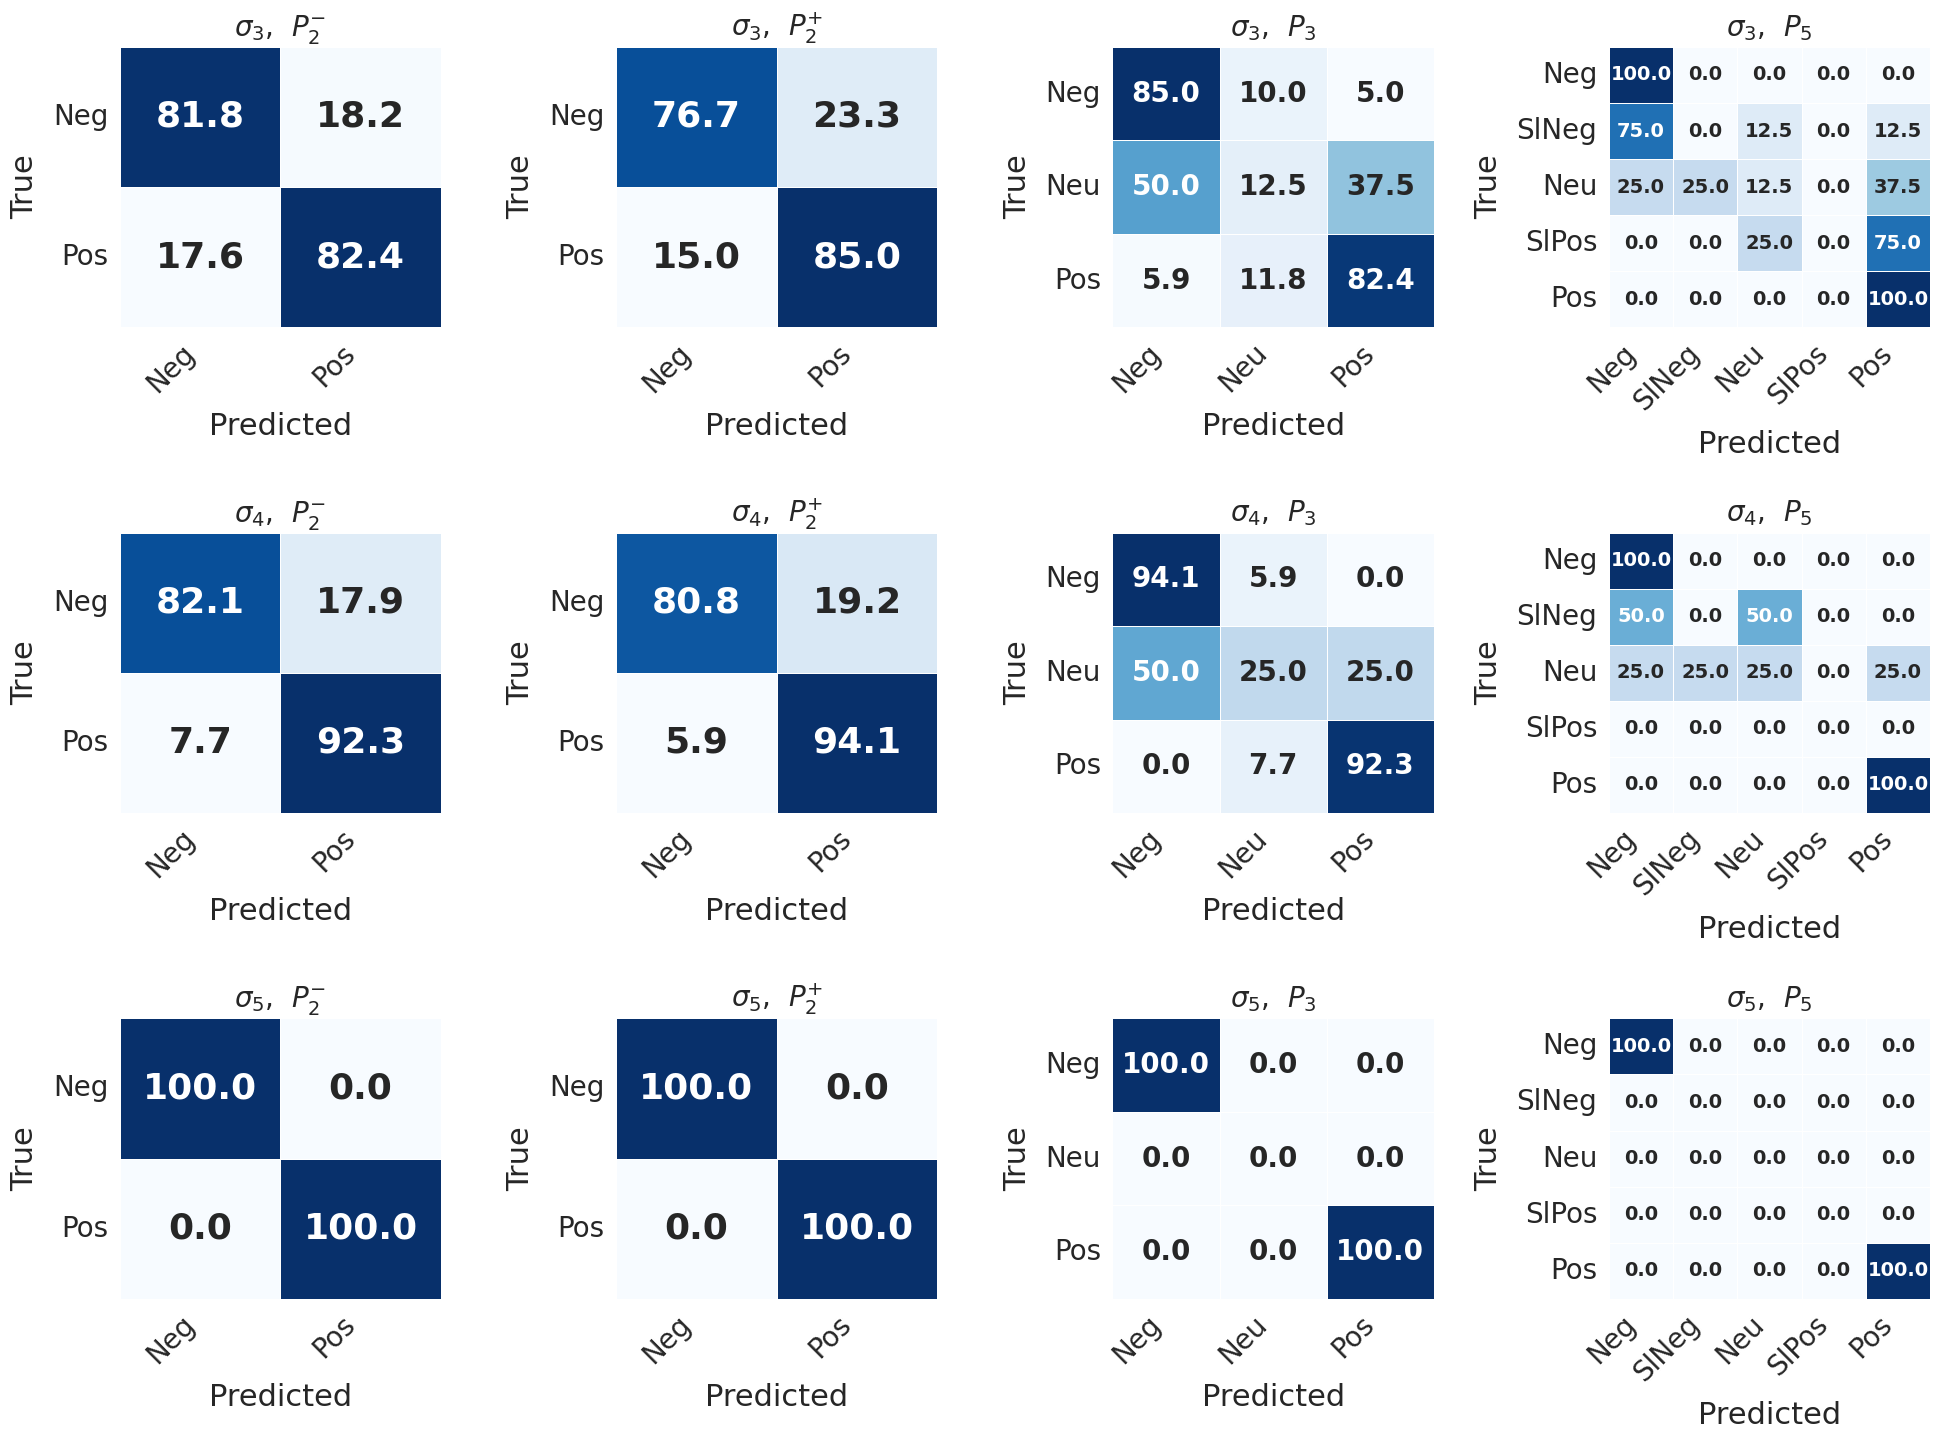

In [7]:
## 7  Confusion Matrices — full annotation pool (all images)
valid_keys_set = set(
    k for k in datasets
    if k in eval_df[eval_df["condition"] == "baseline"]["key"].values
)

SIGMA_ORDER = ["sigma3", "sigma4", "sigma5"]
P_ORDER     = ["p2neg",  "p2plus", "p3",   "p5"]

SIGMA_LABEL = {
    "sigma3": r"$\sigma_3$",
    "sigma4": r"$\sigma_4$",
    "sigma5": r"$\sigma_5$",
}
P_LABEL = {
    "p2neg":  r"$P_2^{-}$",
    "p2plus": r"$P_2^{+}$",
    "p3":     r"$P_3$",
    "p5":     r"$P_5$",
}

tick_map = {
    "binary":       ["Neg", "Pos"],
    "multiclass-3": ["Neg", "Neu", "Pos"],
    "ordinal-5":    ["Neg", "SlNeg", "Neu", "SlPos", "Pos"],
}

# annotation font scales down as the matrix grows
ANNOT_FS = {2: 26, 3: 20, 5: 14}

ncols = len(P_ORDER)
nrows = len(SIGMA_ORDER)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 5))

for row_i, sigma in enumerate(SIGMA_ORDER):
    for col_j, p_key in enumerate(P_ORDER):
        ax  = axes[row_i][col_j]
        key = f"{sigma}_{p_key}"

        if key not in valid_keys_set:
            ax.set_visible(False)
            continue

        p_type = key.split("_", 1)[1]
        smap   = SENTIMENT_MAPS[p_type]
        labels = sorted(set(smap.values()))
        if PROBLEM_TYPE[p_type] == "multiclass-3":
            labels = [1, 0, 2]

        merged = datasets[key].merge(modal_base_full, on="image_id", how="inner")
        if merged.empty:
            ax.set_visible(False)
            continue

        y_true = merged["ground_truth"].values
        y_pred = merged["modal_sentiment"].map(smap).values
        cm     = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

        n_cls    = len(labels)
        annot_fs = ANNOT_FS.get(n_cls, max(10, 26 - (n_cls - 2) * 4))

        sns.heatmap(cm * 100, annot=True, fmt=".1f", cmap="Blues",
                    annot_kws={"fontsize": annot_fs, "fontweight": "bold"},
                    xticklabels=tick_map[PROBLEM_TYPE[p_type]],
                    yticklabels=tick_map[PROBLEM_TYPE[p_type]],
                    linewidths=0.5, cbar=False, ax=ax)

        ax.set_xlabel("Predicted", fontsize=22, labelpad=10)
        ax.set_ylabel("True", fontsize=22, labelpad=10)
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=20, rotation=45, ha="right")
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=20, rotation=0)
        ax.set_title(
            f"{SIGMA_LABEL[sigma]},  {P_LABEL[p_key]}",
            fontsize=20, pad=8,
        )

plt.tight_layout(pad=2.0)
_save_fig(fig, "fig_pa05_confusion_baseline")
plt.show()

In [8]:
## 8  Summary Table — all conditions
shared_cols = ['key', 'p_type', 'problem', 'condition', 'n_images', 'ann_per_image']
metric_cols = ['accuracy_mean', 'f1_macro_mean', 'cohen_kappa_mean',
               'f1_pos_mean', 'roc_auc_mean', 'mae_mean']
avail_cols  = shared_cols + [c for c in metric_cols if c in eval_df.columns]

summary = (eval_df[avail_cols]
           .sort_values(['p_type', 'key', 'condition'])
           .reset_index(drop=True))

COND_DISPLAY = {
    'baseline':            'Baseline (demographic persona)',
    'no_persona_think':    'No-persona think=True',
    'no_persona_no_think': 'No-persona think=False',
}
summary['condition'] = summary['condition'].map(COND_DISPLAY).fillna(summary['condition'])

fmt_dict = {c: '{:.4f}' for c in metric_cols if c in summary.columns}
display(
    summary.style
    .set_caption(
        f'Agreement metrics — all conditions, image bootstrap CI (N={N_BOOTSTRAP}). '
        'Baseline: 1,200 demographic personas × 50 images (modal over ~1,194 ann/image). '
        'No-persona: qwen3-vl:8b, 1 annotation/image, same 50 images as baseline.'
    )
    .hide(axis='index')
    .format(fmt_dict, na_rep='—')
)

# ── Export LaTeX ──────────────────────────────────────────────────────────────
tex = summary.to_latex(
    index=False,
    caption=(
        'Evaluation metrics per agreement subset $(\\sigma, p)$ and condition. '
        'Baseline: 1,200 demographic personas $\\times$ 50 images; '
        'no-persona conditions: \\texttt{qwen3-vl:8b} without persona conditioning, '
        'same 50 images, \\texttt{think=True} and \\texttt{think=False} variants. '
        f'Point estimate from {SAMPLE_FRAC:.0%} annotation resampling per image; '
        f'95\\% CI via image bootstrap ($N={N_BOOTSTRAP}$, seed {BOOTSTRAP_SEED}). '
        "Cohen's $\\kappa$ weighting: unweighted (binary), linear (3-class), "
        'quadratic (ordinal-5). '
        'Macro F1 is the primary metric.'
    ),
    label='tab:perceptsent_agreement_eval',
    escape=True,
    float_format='{:.4f}'.format,
    na_rep='---',
)
tex_path = FIGURES_DIR / 'table3_perceptsent_agreement_eval.tex'
tex_path.write_text(tex)
print(f'LaTeX table saved → {tex_path}')

key,p_type,problem,condition,n_images,ann_per_image,accuracy_mean,f1_macro_mean,cohen_kappa_mean,f1_pos_mean,roc_auc_mean,mae_mean
sigma3_p2neg,p2neg,binary,Baseline (demographic persona),50,716,0.8200,0.8069,0.6154,0.7568,0.8209,—
sigma3_p2neg,p2neg,binary,No-persona think=False,50,1,0.9000,0.8831,0.7672,0.8387,0.8672,—
sigma3_p2neg,p2neg,binary,No-persona think=True,50,1,0.8600,0.8417,0.6835,0.7879,0.8369,—
sigma4_p2neg,p2neg,binary,Baseline (demographic persona),41,716,0.8537,0.8423,0.6878,0.8000,0.8723,—
sigma4_p2neg,p2neg,binary,No-persona think=False,41,1,0.9512,0.9437,0.8874,0.9231,0.9437,—
sigma4_p2neg,p2neg,binary,No-persona think=True,41,1,0.9024,0.8915,0.7836,0.8571,0.9080,—
sigma5_p2neg,p2neg,binary,Baseline (demographic persona),28,716,1.0000,1.0000,1.0000,1.0000,1.0000,—
sigma5_p2neg,p2neg,binary,No-persona think=False,28,1,1.0000,1.0000,1.0000,1.0000,1.0000,—
sigma5_p2neg,p2neg,binary,No-persona think=True,28,1,0.9643,0.9602,0.9205,0.9474,0.9737,—
sigma3_p2plus,p2plus,binary,Baseline (demographic persona),50,716,0.8000,0.7971,0.5968,0.7727,0.8083,—


LaTeX table saved → /mnt/raid5/neemias/mllm-persona-simulation-urbcom/figures/table3_perceptsent_agreement_eval.tex


In [9]:
## 8  Summary Table
shared_cols = ['key', 'p_type', 'problem', 'condition', 'n_images', 'ann_per_image']
metric_cols = ['accuracy_mean', 'f1_macro_mean', 'cohen_kappa_mean',
               'f1_pos_mean', 'roc_auc_mean', 'mae_mean']
avail_cols  = shared_cols + [c for c in metric_cols if c in eval_df.columns]

summary = (eval_df[avail_cols]
           .sort_values(['p_type', 'key', 'condition'])
           .reset_index(drop=True))

fmt_dict = {c: '{:.4f}' for c in metric_cols if c in summary.columns}
display(
    summary.style
    .set_caption(
        f'Agreement metrics — all images, {SAMPLE_FRAC:.0%} annotation resample, '
        f'image bootstrap CI (N={N_BOOTSTRAP})'
    )
    .hide(axis='index')
    .format(fmt_dict, na_rep='—')
)

# ── Export LaTeX ──────────────────────────────────────────────────────────────
tex = summary.to_latex(
    index=False,
    caption=(
        'Evaluation metrics per agreement subset $(\\sigma, p)$ and condition. '
        f'All matched images retained; point estimate from {SAMPLE_FRAC:.0%} '
        'annotation resampling per image; 95\\% CI via image bootstrap '
        f'($N={N_BOOTSTRAP}$, seed {BOOTSTRAP_SEED}). '
        "Cohen's $\\kappa$ weighting: unweighted (binary), linear (3-class), "
        'quadratic (ordinal-5). '
        'Macro F1 is the primary metric following MLLMsent (arXiv:2508.16873).'
    ),
    label='tab:perceptsent_agreement_eval',
    escape=True,
    float_format='{:.4f}'.format,
    na_rep='---',
)
tex_path = FIGURES_DIR / 'table3_perceptsent_agreement_eval.tex'
tex_path.write_text(tex)
print(f'LaTeX table saved → {tex_path}')


key,p_type,problem,condition,n_images,ann_per_image,accuracy_mean,f1_macro_mean,cohen_kappa_mean,f1_pos_mean,roc_auc_mean,mae_mean
sigma3_p2neg,p2neg,binary,baseline,50,716,0.8200,0.8069,0.6154,0.7568,0.8209,—
sigma3_p2neg,p2neg,binary,no_persona_no_think,50,1,0.9000,0.8831,0.7672,0.8387,0.8672,—
sigma3_p2neg,p2neg,binary,no_persona_think,50,1,0.8600,0.8417,0.6835,0.7879,0.8369,—
sigma4_p2neg,p2neg,binary,baseline,41,716,0.8537,0.8423,0.6878,0.8000,0.8723,—
sigma4_p2neg,p2neg,binary,no_persona_no_think,41,1,0.9512,0.9437,0.8874,0.9231,0.9437,—
sigma4_p2neg,p2neg,binary,no_persona_think,41,1,0.9024,0.8915,0.7836,0.8571,0.9080,—
sigma5_p2neg,p2neg,binary,baseline,28,716,1.0000,1.0000,1.0000,1.0000,1.0000,—
sigma5_p2neg,p2neg,binary,no_persona_no_think,28,1,1.0000,1.0000,1.0000,1.0000,1.0000,—
sigma5_p2neg,p2neg,binary,no_persona_think,28,1,0.9643,0.9602,0.9205,0.9474,0.9737,—
sigma3_p2plus,p2plus,binary,baseline,50,716,0.8000,0.7971,0.5968,0.7727,0.8083,—


LaTeX table saved → /mnt/raid5/neemias/mllm-persona-simulation-urbcom/figures/table3_perceptsent_agreement_eval.tex
